In [1]:
# Loan Status Prediction - Heavy Notebook (Full EDA + ML + Advanced Visualizations & Tests)
# Created for user: heavy notebook (option C)
# Make sure 'data.csv' is placed in the same folder as this notebook before running.


In [2]:
# 1) Imports
import warnings
warnings.filterwarnings('ignore')

import os
from datetime import datetime
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Environment check:')
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('sklearn:', sklearn.__version__)
print('xgboost:', xgb.__version__)


Environment check:
pandas: 2.3.3
numpy: 2.3.5
sklearn: 1.8.0
xgboost: 3.1.2


In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data')

FileNotFoundError: [Errno 2] No such file or directory: 'data'

In [ ]:
# 2) Utility functions: load, explore, clean, feature engineering, preprocessing, train, evaluate, save outputs

def load_data(filepath='data.csv'):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found: {filepath} — please put the CSV in the same folder as this notebook.")
    df = pd.read_csv(filepath)
    print('Loaded:', filepath, '->', df.shape)
    return df

def quick_overview(df, n=5):
    print('--- HEAD ---')
    display(df.head(n))
    print('\n--- INFO ---')
    display(df.info())
    print('\n--- NULLS ---')
    display(df.isnull().sum().sort_values(ascending=False).head(20))
    print('\n--- DESCRIPTION (numeric) ---')
    display(df.describe().T)

def clean_data(df):
    df = df.copy()
    # Standard simple cleaning: strip whitespace for object columns
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].astype(str).str.strip()
    # Example missing handling (customize as needed)
    if 'usia' in df.columns:
        df['usia'] = pd.to_numeric(df['usia'], errors='coerce')
        df['usia'].fillna(df['usia'].median(), inplace=True)
    if 'status_pekerjaan' in df.columns:
        df['status_pekerjaan'].replace({'nan':'Unknown'}, inplace=True)
        df['status_pekerjaan'].fillna(df['status_pekerjaan'].mode()[0], inplace=True)
    print('Basic cleaning done.')
    return df

def engineer_features(df):
    df = df.copy()
    if 'usia' in df.columns:
        df['age_group'] = pd.cut(df['usia'], bins=[0,25,35,45,55,100], labels=['18-25','26-35','36-45','46-55','55+'])
    if 'pendapatan_tahunan' in df.columns:
        df['income_group'] = pd.cut(df['pendapatan_tahunan'], bins=[-1,30000,50000,75000,250000], labels=['Low','Medium','High','Very High'])
    # composite risk (example if columns exist)
    comp_cols = [c for c in ['gagal_bayar_tercatat','tunggakan_2thn_terakhir','catatan_negatif','rasio_hutang_terhadap_pendapatan'] if c in df.columns]
    if comp_cols:
        df['risk_score'] = sum([(df[c].fillna(0).astype(float))*(w) for c,w in zip(comp_cols, [0.3,0.2,0.2,0.3][:len(comp_cols)])])
    print('Feature engineering done.')
    return df

def preprocess_for_ml(df, feature_list=None, test_size=0.2, random_state=42):
    df_ml = df.copy()
    # Encode common categorical columns
    enc = LabelEncoder()
    for col in ['status_pekerjaan','tipe_produk','tujuan_pinjaman']:
        if col in df_ml.columns:
            df_ml[col] = enc.fit_transform(df_ml[col].astype(str))
    # If feature_list provided, use, else pick numeric columns excluding target
    if feature_list is None:
        numeric = df_ml.select_dtypes(include=['int64','float64']).columns.tolist()
        numeric = [c for c in numeric if c!='status_pinjaman']
        feature_list = numeric
    X = df_ml[feature_list].fillna(0)
    y = df_ml['status_pinjaman']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    print('Preprocessing done. Features used:', len(feature_list))
    return X_train_s, X_test_s, y_train, y_test, feature_list, scaler

def train_models(X_train, X_test, y_train, y_test):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(max_depth=10),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200),
        'XGBoost': xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        'SVM': SVC(probability=True),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }
    results = {}
    for name, model in models.items():
        print('\nTraining', name)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # predict_proba may not exist for some models; handle safely
        y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None
        results[name] = {
            'model': model,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None
        }
        print(f"{name} done. F1: {results[name]['f1']:.4f}")
    return results

def evaluate_and_save(results, y_test, feature_names, output_dir='outputs'):
    os.makedirs(output_dir, exist_ok=True)
    # Create metrics DF
    rows = []
    for name, r in results.items():
        rows.append([name, r['accuracy'], r['precision'], r['recall'], r['f1'], r['roc_auc'] if r['roc_auc'] else 0])
    metrics_df = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1','ROC_AUC']).sort_values('F1', ascending=False)
    metrics_df.to_csv(os.path.join(output_dir,'model_comparison.csv'), index=False)
    display(metrics_df)
    # save models? (optional)
    return metrics_df


In [ ]:
# 3) Run: Load -> Explore -> Clean -> Feature engineering
# Update the filename here if your data has a different name
DATA_PATH = 'data.csv'

df = load_data(DATA_PATH)
quick_overview(df)
df_clean = clean_data(df)
df_fe = engineer_features(df_clean)
print('\nWorking dataframe shape:', df_fe.shape)


Loaded: data.csv -> (50000, 20)
--- HEAD ---


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0,Bekerja,17.2,25579,692,5.3,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33.0,Bekerja,7.3,43087,627,3.5,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42.0,Mahasiswa,1.1,20840,689,8.4,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53.0,Mahasiswa,0.5,29147,692,9.8,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32.0,Bekerja,12.5,63657,630,7.2,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.92,0.195,1.565,0.522,1



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id_pelanggan                          50000 non-null  object 
 1   usia                                  49853 non-null  float64
 2   status_pekerjaan                      49847 non-null  object 
 3   lama_bekerja_tahun                    50000 non-null  float64
 4   pendapatan_tahunan                    50000 non-null  int64  
 5   skor_kredit                           50000 non-null  int64  
 6   lama_riwayat_kredit_tahun             50000 non-null  float64
 7   aset_tabungan                         50000 non-null  int64  
 8   hutang_saat_ini                       50000 non-null  int64  
 9   gagal_bayar_tercatat                  50000 non-null  int64  
 10  tunggakan_2thn_terakhir               50000 non-null  int64  
 11  c

None


--- NULLS ---


status_pekerjaan                        153
usia                                    147
id_pelanggan                              0
lama_bekerja_tahun                        0
pendapatan_tahunan                        0
skor_kredit                               0
lama_riwayat_kredit_tahun                 0
aset_tabungan                             0
hutang_saat_ini                           0
gagal_bayar_tercatat                      0
tunggakan_2thn_terakhir                   0
catatan_negatif                           0
tipe_produk                               0
tujuan_pinjaman                           0
jumlah_pinjaman                           0
suku_bunga                                0
rasio_hutang_terhadap_pendapatan          0
rasio_pinjaman_terhadap_pendapatan        0
rasio_pembayaran_terhadap_pendapatan      0
status_pinjaman                           0
dtype: int64


--- DESCRIPTION (numeric) ---


,count,mean,std,min,25%,50%,75%,max
usia,49853.0,34.957034,11.115165,18.000,26.000,35.000,43.00000,70.000
lama_bekerja_tahun,50000.0,7.454868,7.612097,0.000,1.300,4.900,11.40000,39.900
pendapatan_tahunan,50000.0,50062.892040,32630.501014,15000.000,27280.500,41607.500,62723.25000,250000.000
skor_kredit,50000.0,643.614820,64.731518,348.000,600.000,643.000,687.00000,850.000
lama_riwayat_kredit_tahun,50000.0,8.168274,7.207552,0.000,2.000,6.100,12.60000,30.000
aset_tabungan,50000.0,3595.619400,13232.399398,0.000,130.000,568.000,2271.00000,300000.000
hutang_saat_ini,50000.0,14290.442220,13243.757493,60.000,5581.000,10385.000,18449.25000,163344.000
gagal_bayar_tercatat,50000.0,0.053480,0.224991,0.000,0.000,0.000,0.00000,1.000
tunggakan_2thn_terakhir,50000.0,0.554640,0.845050,0.000,0.000,0.000,1.00000,9.000
catatan_negatif,50000.0,0.147640,0.412996,0.000,0.000,0.000,0.00000,4.000


Basic cleaning done.
Feature engineering done.

Working dataframe shape: (50000, 23)


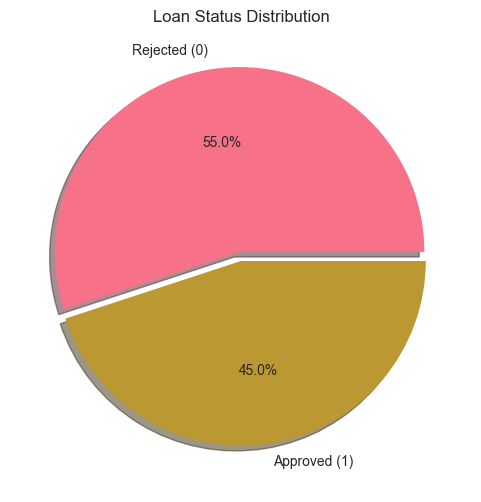

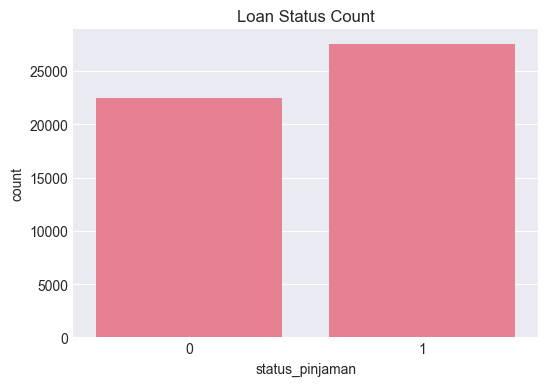

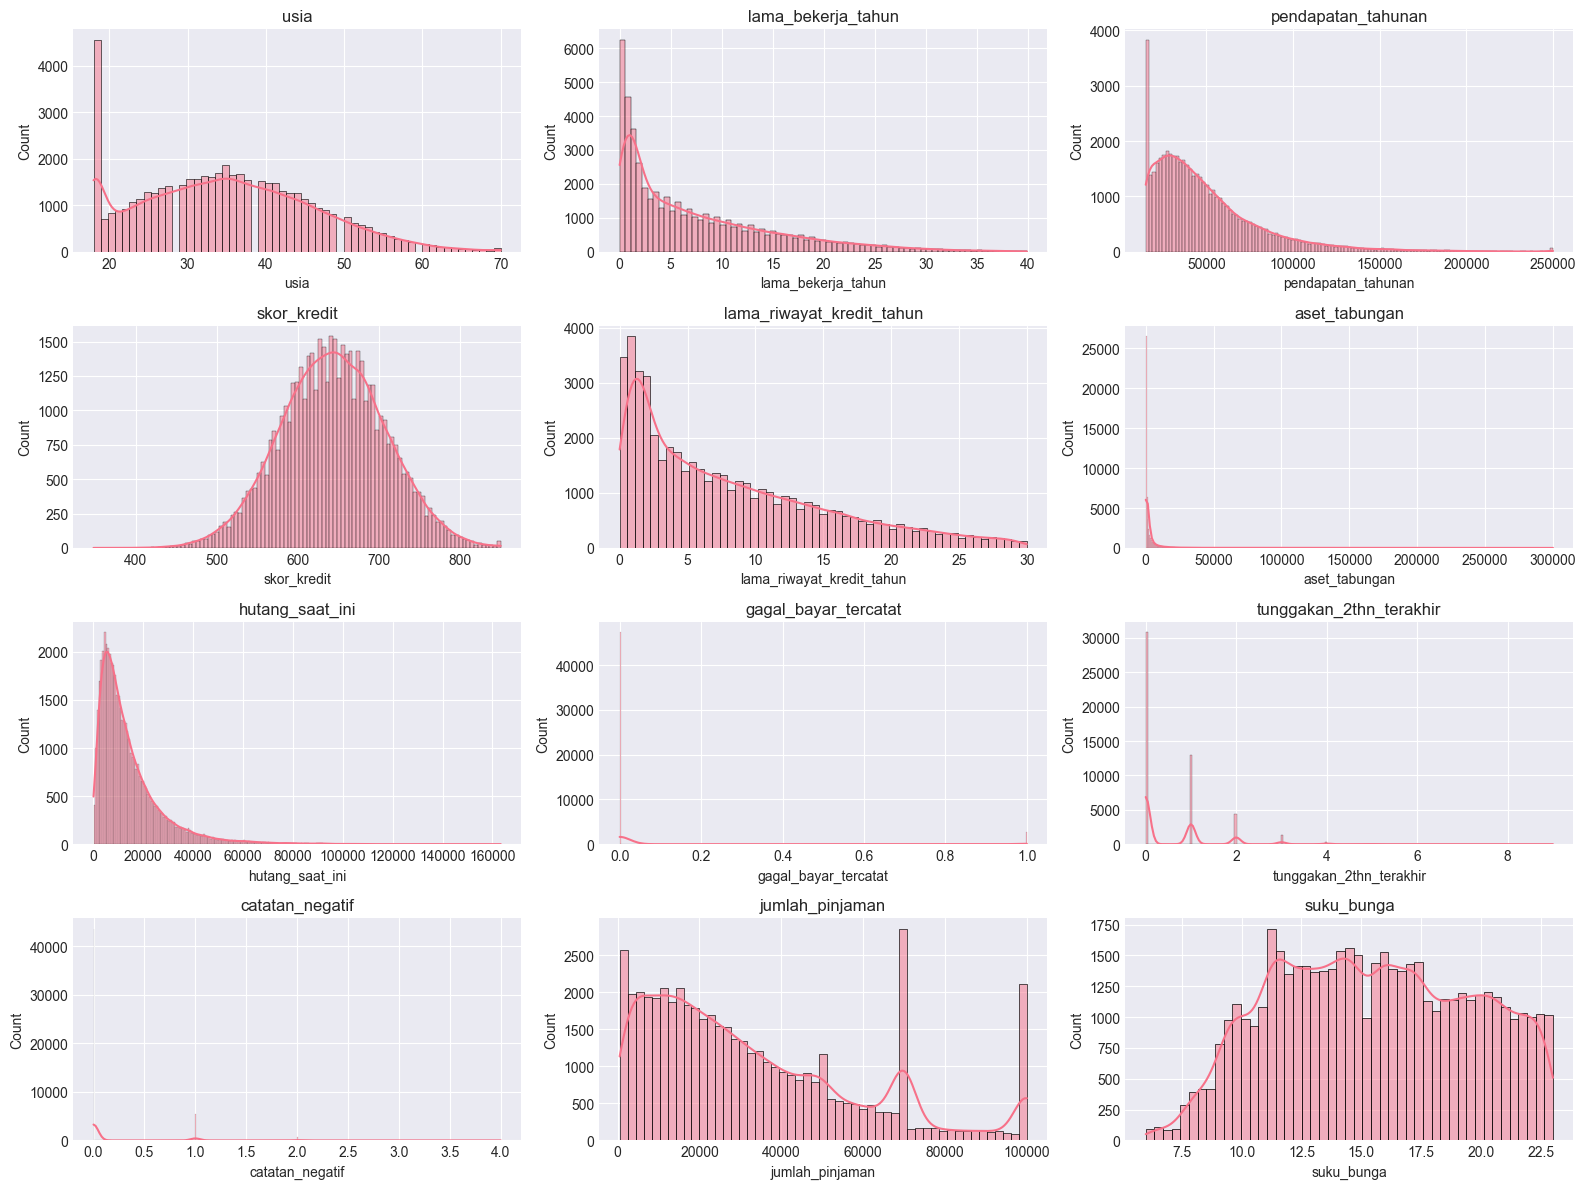

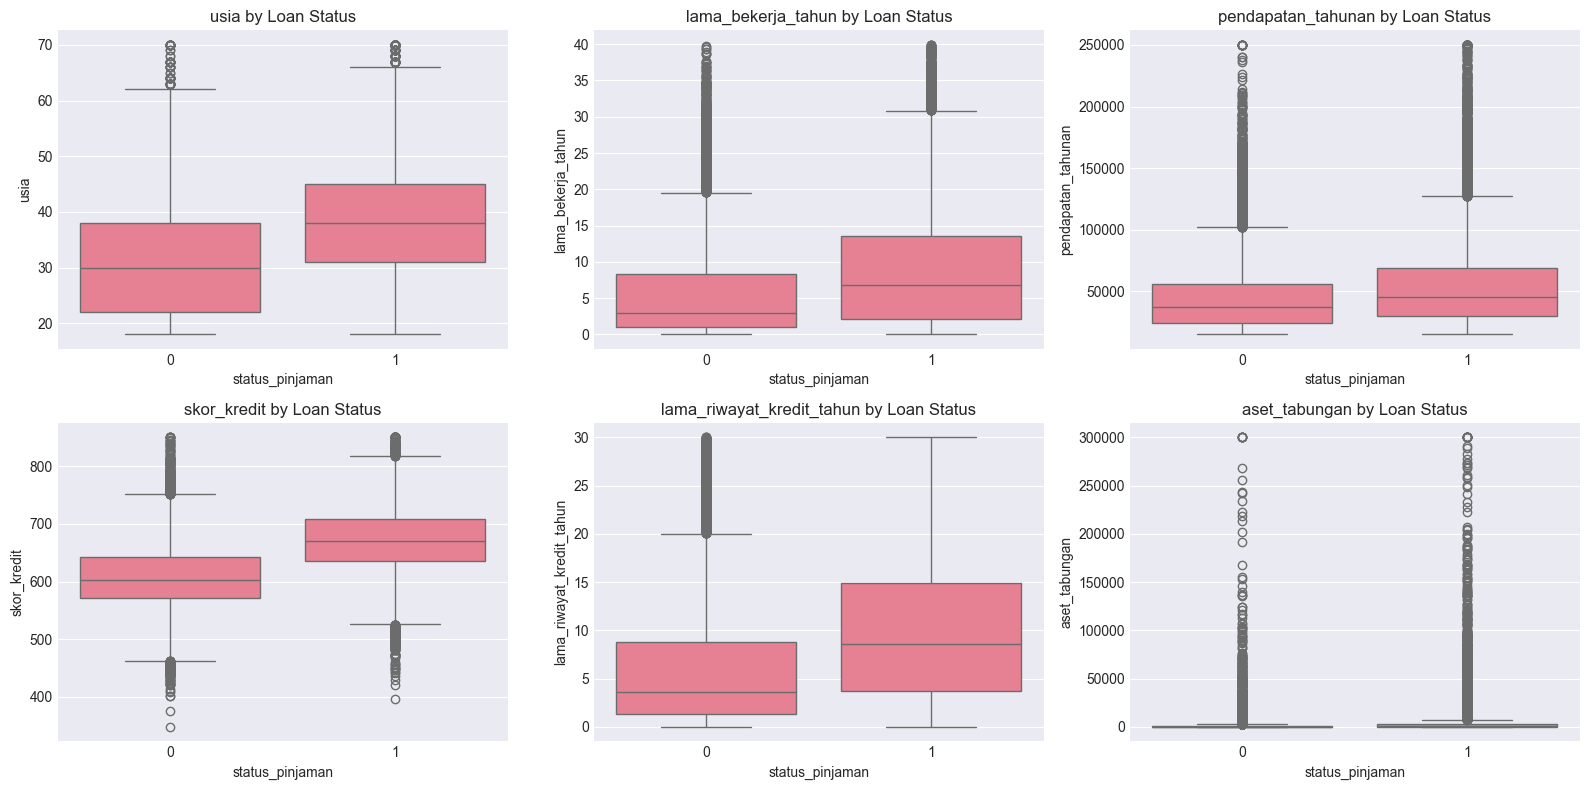

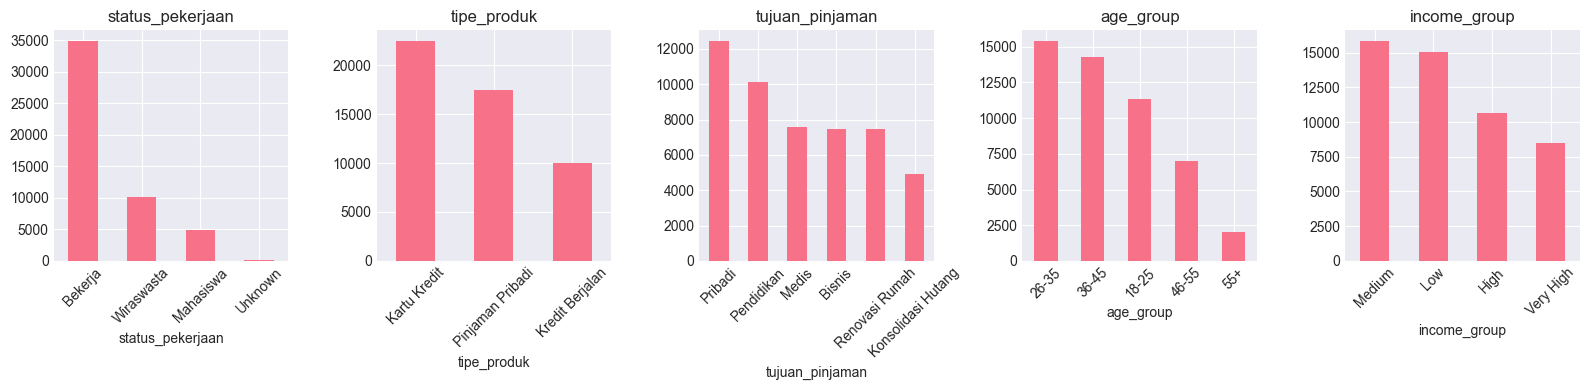

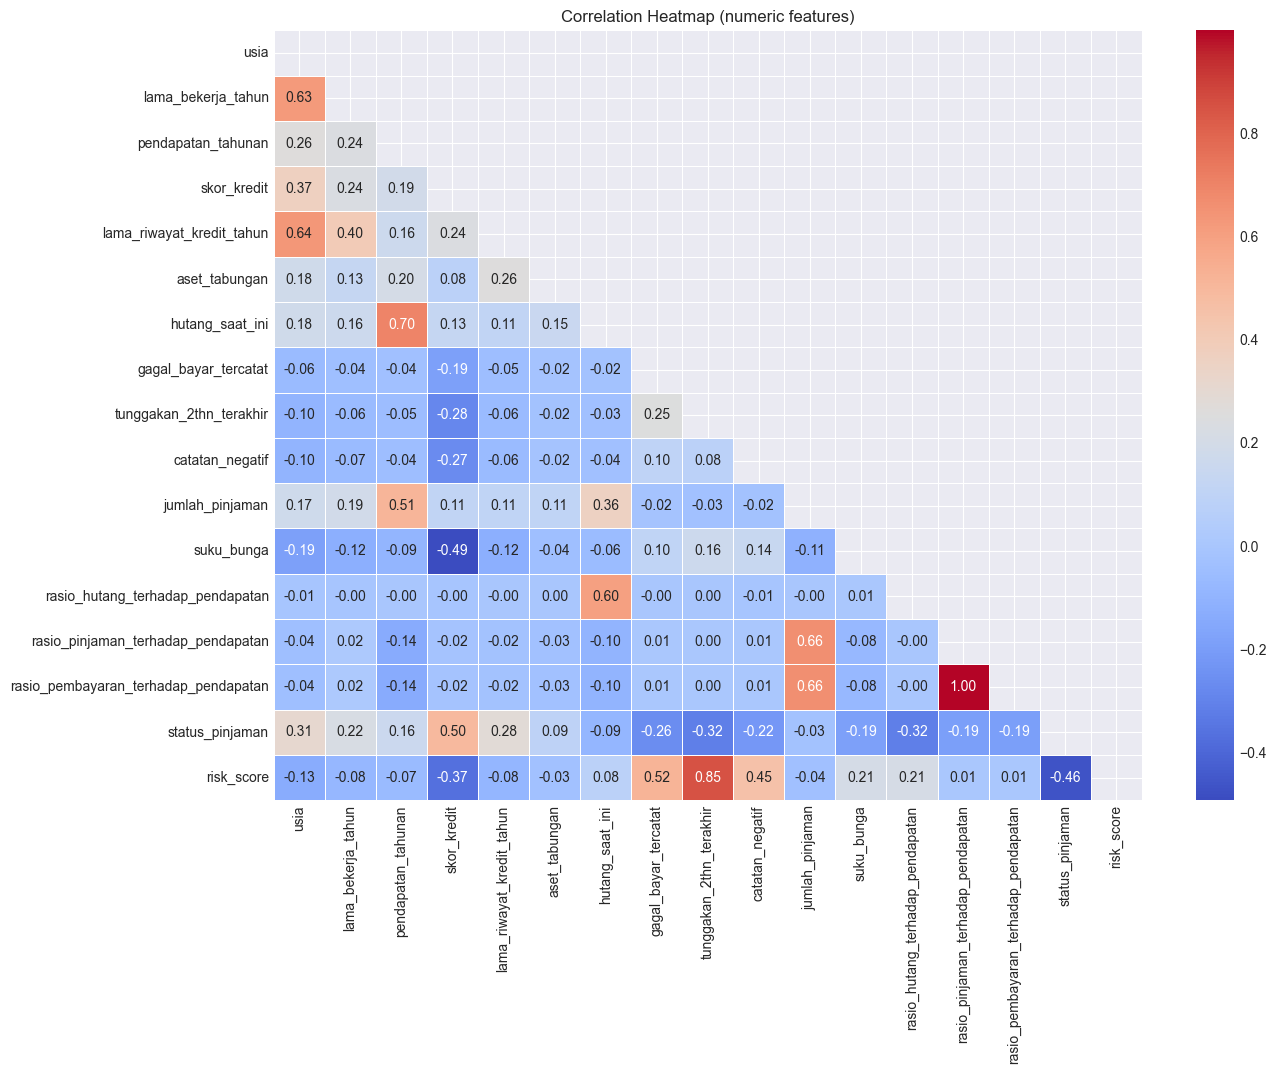

In [ ]:
# 4) Extended EDA - Matplotlib & Seaborn visuals (save to outputs/)
out_dir = 'outputs'
os.makedirs(out_dir, exist_ok=True)

# 4.1 Target distribution - pie & bar
plt.figure(figsize=(6,6))
counts = df_fe['status_pinjaman'].value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', labels=['Rejected (0)','Approved (1)'], explode=[0.05,0], shadow=True)
plt.title('Loan Status Distribution')
plt.ylabel('')
plt.savefig(os.path.join(out_dir,'01_target_pie.png'), bbox_inches='tight', dpi=150)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='status_pinjaman', data=df_fe)
plt.title('Loan Status Count')
plt.savefig(os.path.join(out_dir,'02_target_bar.png'), bbox_inches='tight', dpi=150)
plt.show()

# 4.2 Numeric distributions (histograms + KDE)
num_cols = df_fe.select_dtypes(include=['int64','float64']).columns.tolist()
if 'status_pinjaman' in num_cols:
    num_cols.remove('status_pinjaman')

plt.figure(figsize=(16,12))
for i, col in enumerate(num_cols[:12],1):
    plt.subplot(4,3,i)
    sns.histplot(df_fe[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.savefig(os.path.join(out_dir,'03_numeric_histograms.png'), dpi=150)
plt.show()

# 4.3 Boxplots for key numeric features
plt.figure(figsize=(16,8))
for i, col in enumerate(num_cols[:6],1):
    plt.subplot(2,3,i)
    sns.boxplot(x='status_pinjaman', y=col, data=df_fe)
    plt.title(f'{col} by Loan Status')
plt.tight_layout()
plt.savefig(os.path.join(out_dir,'04_boxplots.png'), dpi=150)
plt.show()

# 4.4 Categorical counts
cat_cols = [c for c in ['status_pekerjaan','tipe_produk','tujuan_pinjaman','age_group','income_group'] if c in df_fe.columns]
plt.figure(figsize=(16,4))
for i, col in enumerate(cat_cols,1):
    plt.subplot(1,len(cat_cols),i)
    df_fe[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(out_dir,'05_categorical_counts.png'), dpi=150)
plt.show()

# 4.5 Correlation heatmap (numeric only)
numeric_df = df_fe.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(14,10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (numeric features)')
plt.savefig(os.path.join(out_dir,'06_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 5) Statistical tests & insights
# Chi-square for categorical vs target (if available)
for col in cat_cols:
    ct = pd.crosstab(df_fe[col], df_fe['status_pinjaman'])
    try:
        chi2, p, dof, ex = chi2_contingency(ct)
        print(f'Chi2 for {col}: p-value = {p:.4g}')
    except Exception as e:
        print('Chi2 error for', col, e)

# t-test for numeric features between approved vs rejected (top features)
if 'status_pinjaman' in df_fe.columns:
    approved = df_fe[df_fe['status_pinjaman']==1]
    rejected = df_fe[df_fe['status_pinjaman']==0]
    for col in numeric_df.columns[:8]:
        t, p = stats.ttest_ind(approved[col].dropna(), rejected[col].dropna(), equal_var=False)
        print(f'T-test {col}: p-value = {p:.4g}')


Chi2 for status_pekerjaan: p-value = 4.021e-05
Chi2 for tipe_produk: p-value = 8.049e-157
Chi2 for tujuan_pinjaman: p-value = 0
Chi2 for age_group: p-value = 0
Chi2 for income_group: p-value = 5.596e-266
T-test usia: p-value = 0
T-test lama_bekerja_tahun: p-value = 0
T-test pendapatan_tahunan: p-value = 1.487e-291
T-test skor_kredit: p-value = 0
T-test lama_riwayat_kredit_tahun: p-value = 0
T-test aset_tabungan: p-value = 4.112e-109
T-test hutang_saat_ini: p-value = 7.217e-84
T-test gagal_bayar_tercatat: p-value = 0


In [ ]:
# 6) Preprocessing for ML (STEP 1)
X_train, X_test, y_train, y_test, feature_cols, scaler = preprocess_for_ml(df_fe)
print('Shapes:', X_train.shape, X_test.shape)


Preprocessing done. Features used: 19
Shapes: (40000, 19) (10000, 19)


In [ ]:
# 7) Train models (STEP 2) - this will create 'results'
results = train_models(X_train, X_test, y_train, y_test)



Training Logistic Regression
Logistic Regression done. F1: 0.8600

Training Decision Tree
Decision Tree done. F1: 0.8999

Training Random Forest


In [ ]:
# 8) Evaluation & Save metrics
metrics_df = evaluate_and_save(results, y_test, feature_cols, output_dir=out_dir)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.9275,0.925116,0.944777,0.934843,0.983463
4,XGBoost,0.9247,0.925349,0.938965,0.932107,0.982581
2,Random Forest,0.9105,0.911607,0.927339,0.919406,0.973676
5,SVM,0.8988,0.902526,0.914986,0.908714,0.966487
1,Decision Tree,0.8873,0.879376,0.921708,0.900044,0.947373
6,KNN,0.8642,0.853417,0.909537,0.880584,0.932634
0,Logistic Regression,0.8437,0.848233,0.872116,0.860009,0.927918


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


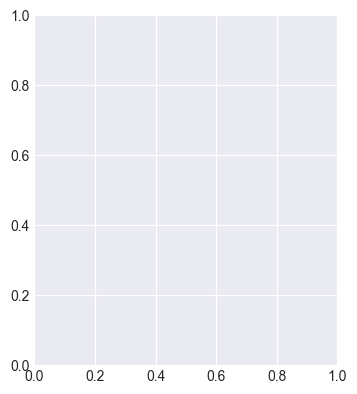

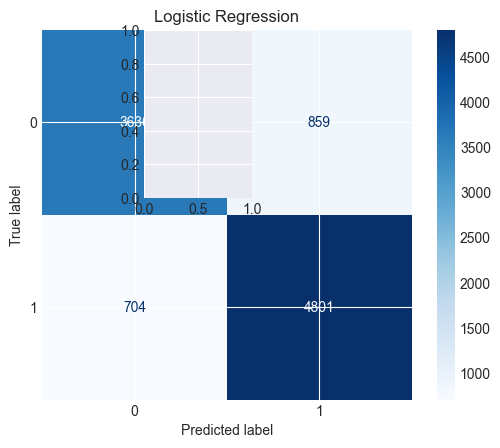

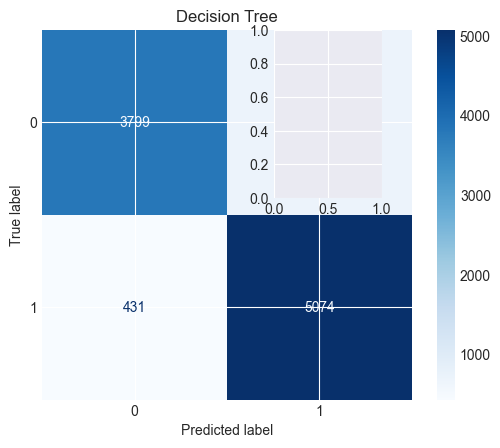

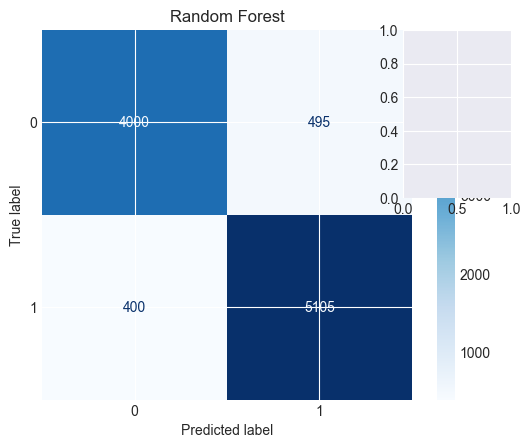

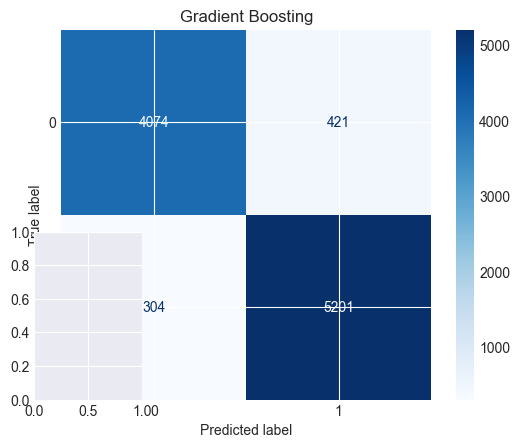

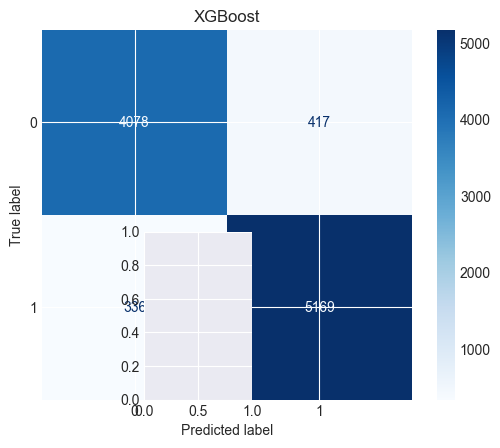

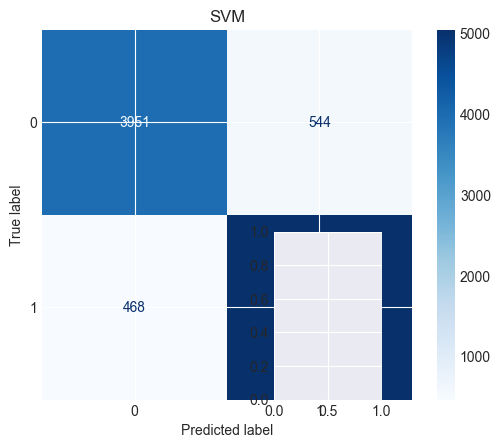

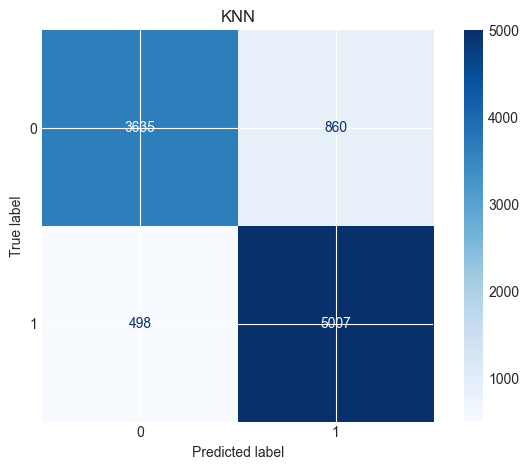

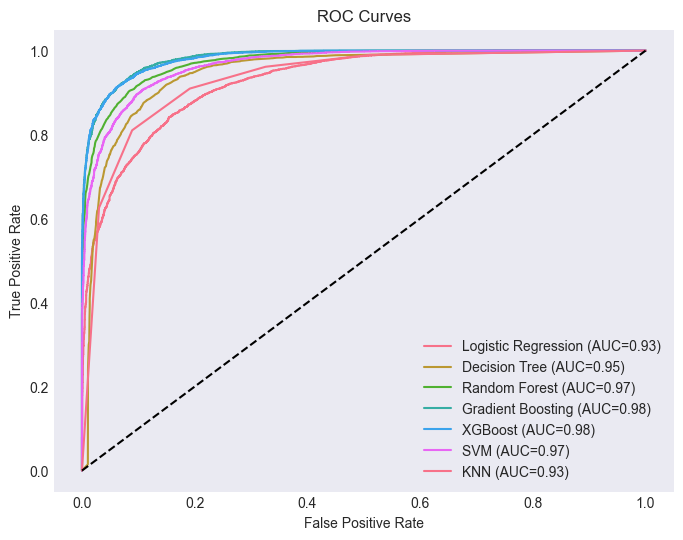

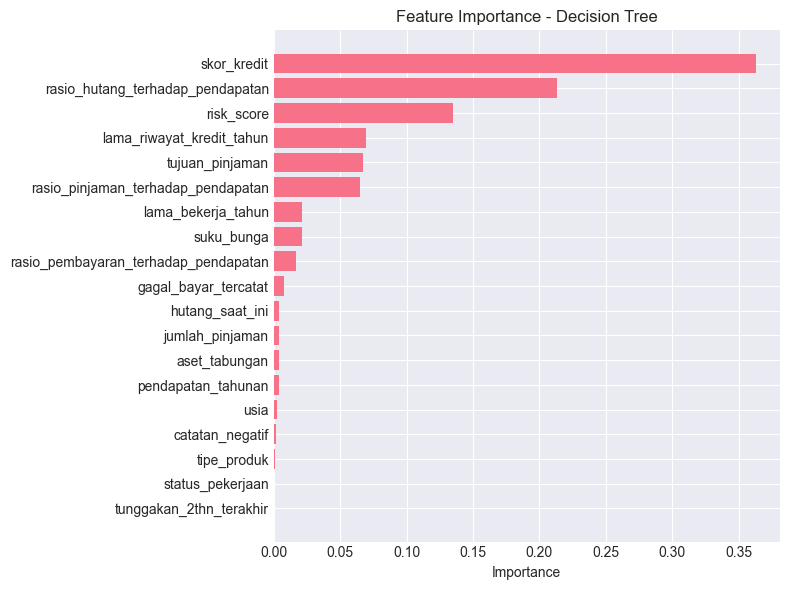

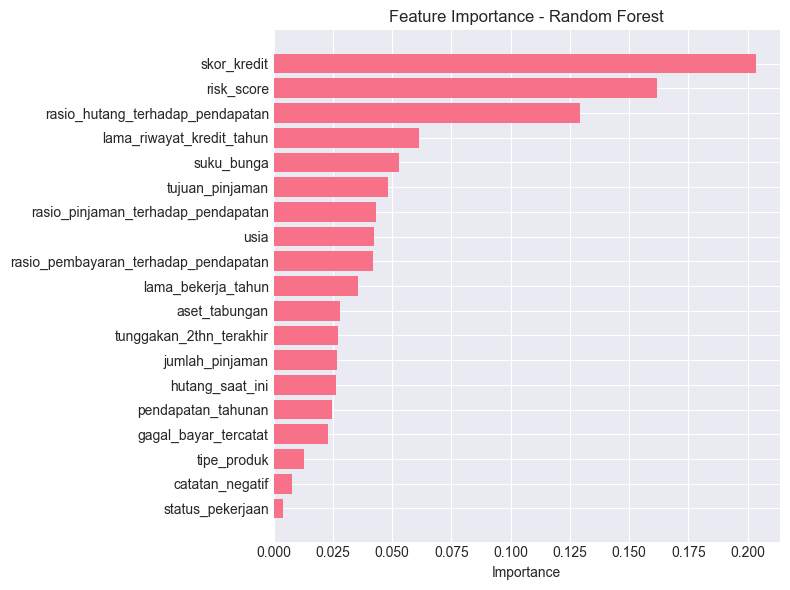

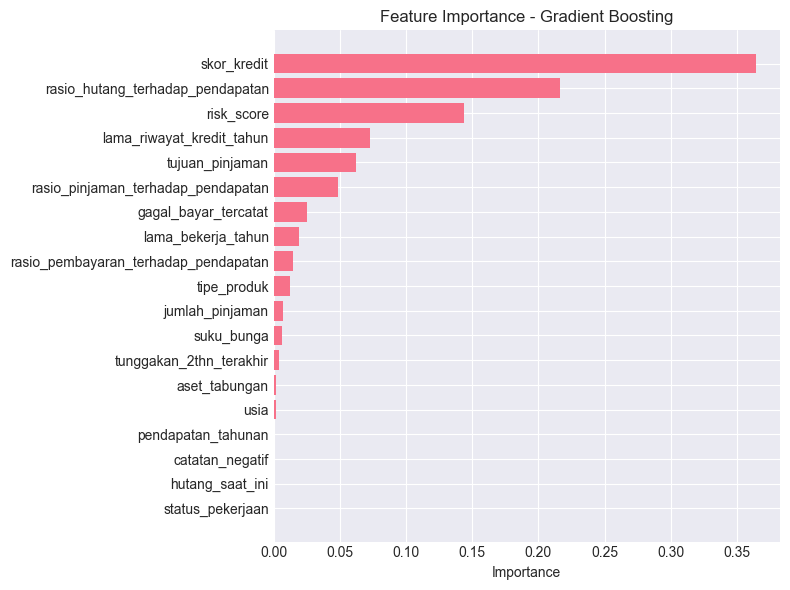

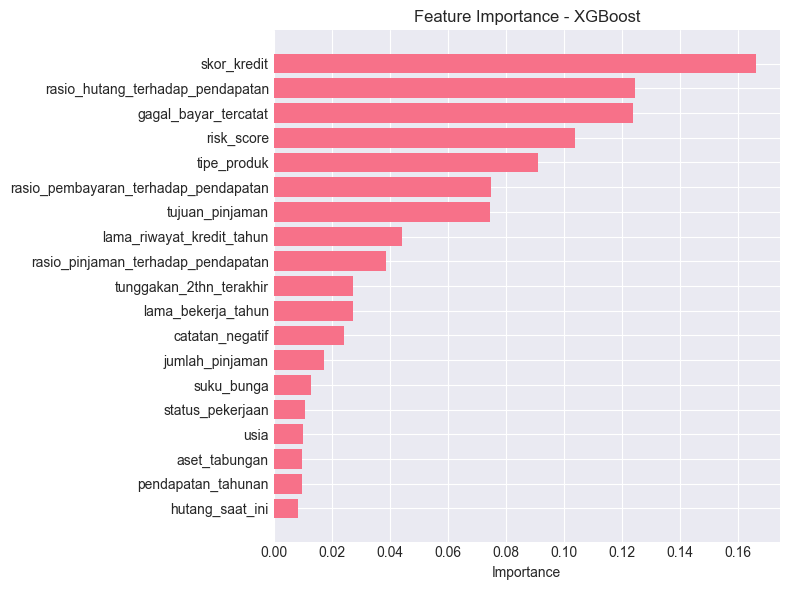

In [ ]:
# 9) Confusion matrices & ROC & Feature importance visualizations

# Confusion matrices
plt.figure(figsize=(18,10))
for i, (name, r) in enumerate(results.items(),1):
    plt.subplot(2,4,i)
    ConfusionMatrixDisplay.from_predictions(y_test, r['y_pred'], cmap='Blues', values_format='d')
    plt.title(name)
plt.tight_layout()
plt.savefig(os.path.join(out_dir,'07_confusion_matrices.png'), dpi=150)
plt.show()

# ROC curves (only for models with y_proba)
plt.figure(figsize=(8,6))
for name, r in results.items():
    if r.get('y_proba') is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        auc = roc_auc_score(y_test, r['y_proba'])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid()
plt.savefig(os.path.join(out_dir,'08_roc_curves.png'), dpi=150)
plt.show()

# Feature importance for tree-based models
for name, r in results.items():
    model = r['model']
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        idx = np.argsort(imp)
        plt.figure(figsize=(8,6))
        plt.barh(np.array(feature_cols)[idx], imp[idx])
        plt.title(f'Feature Importance - {name}')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir,f'09_feature_importance_{name.replace(" ","_")}.png'), dpi=150)
        plt.show()


In [ ]:
# 10) Save notebook outputs summary
summary = {
    'run_time': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_shape': df_fe.shape,
    'top_models': metrics_df.head().to_dict(orient='records')
}
with open(os.path.join(out_dir,'run_summary.json'),'w') as f:
    json.dump(summary, f, indent=2)
print('Saved outputs to', out_dir)


Saved outputs to outputs
